# Weather Scenario Analysis

This notebook analyzes the historical weather data to define "likely weather scenarios" (e.g., Sunny, Cloudy, Overcast) that can be used for power generation forecasting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# Set plot style
plt.style.use('ggplot')
sns.set_palette('viridis')

## 1. Data Loading and Daily Aggregation

We'll characterize each day by its total irradiation and temperature profile.

In [2]:
w1 = pd.read_csv('../../data/Plant_1_Weather_Sensor_Data (2).csv')
w2 = pd.read_csv('../../data/Plant_2_Weather_Sensor_Data (1).csv')

w1['DATE_TIME'] = pd.to_datetime(w1['DATE_TIME'])
w2['DATE_TIME'] = pd.to_datetime(w2['DATE_TIME'])

weather = pd.concat([w1, w2])
weather['DATE'] = weather['DATE_TIME'].dt.date

# Daily characteristics: Total Irradiation, Max Temp, Avg Temp
daily_weather = weather.groupby(['DATE', 'PLANT_ID']).agg({
    'IRRADIATION': 'sum',
    'AMBIENT_TEMPERATURE': ['max', 'mean'],
    'MODULE_TEMPERATURE': ['max', 'mean']
}).reset_index()

# Flatten columns
daily_weather.columns = ['DATE', 'PLANT_ID', 'TOTAL_IRRADIATION', 'MAX_AMBIENT_TEMP', 'AVG_AMBIENT_TEMP', 'MAX_MODULE_TEMP', 'AVG_MODULE_TEMP']

daily_weather.head()

,DATE,PLANT_ID,TOTAL_IRRADIATION,MAX_AMBIENT_TEMP,AVG_AMBIENT_TEMP,MAX_MODULE_TEMP,AVG_MODULE_TEMP
0,2020-05-15,4135001,19.037010,34.430943,27.430823,55.030613,32.582964
1,2020-05-15,4136001,28.559055,37.352829,30.565992,60.389377,35.559493
2,2020-05-16,4135001,18.651690,32.524149,26.780538,54.232746,31.858851
3,2020-05-16,4136001,23.676573,36.358956,29.478612,66.016279,35.143314
4,2020-05-17,4135001,22.931378,35.252486,26.686727,63.145582,32.740435


## 2. Defining Weather Scenarios via Clustering

We use KMeans clustering to group days into categories based on their solar potential and temperature.

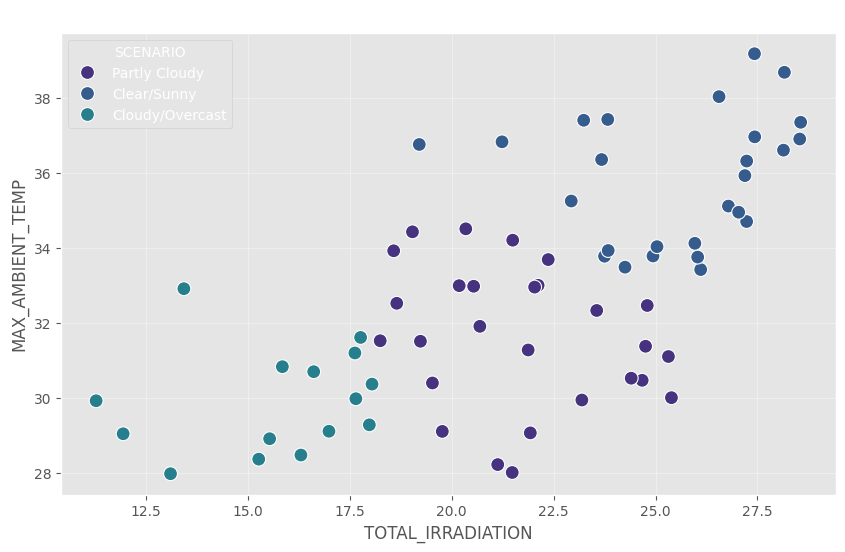

In [3]:
features = ['TOTAL_IRRADIATION', 'MAX_AMBIENT_TEMP']
X = daily_weather[features]

# Normalize
X_norm = (X - X.mean()) / X.std()

kmeans = KMeans(n_clusters=3, random_state=42)
daily_weather['SCENARIO_ID'] = kmeans.fit_predict(X_norm)

# Map Scenario IDs to labels based on irradiation levels
centers = daily_weather.groupby('SCENARIO_ID')['TOTAL_IRRADIATION'].mean().sort_values()
mapping = {centers.index[0]: 'Cloudy/Overcast', centers.index[1]: 'Partly Cloudy', centers.index[2]: 'Clear/Sunny'}
daily_weather['SCENARIO'] = daily_weather['SCENARIO_ID'].map(mapping)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=daily_weather, x='TOTAL_IRRADIATION', y='MAX_AMBIENT_TEMP', hue='SCENARIO', s=100)
plt.title('Weather Scenario Clusters')
plt.show()

## 3. Scenario Profiles (24-hour patterns)

Let's extract the average 15-minute profile for each scenario.

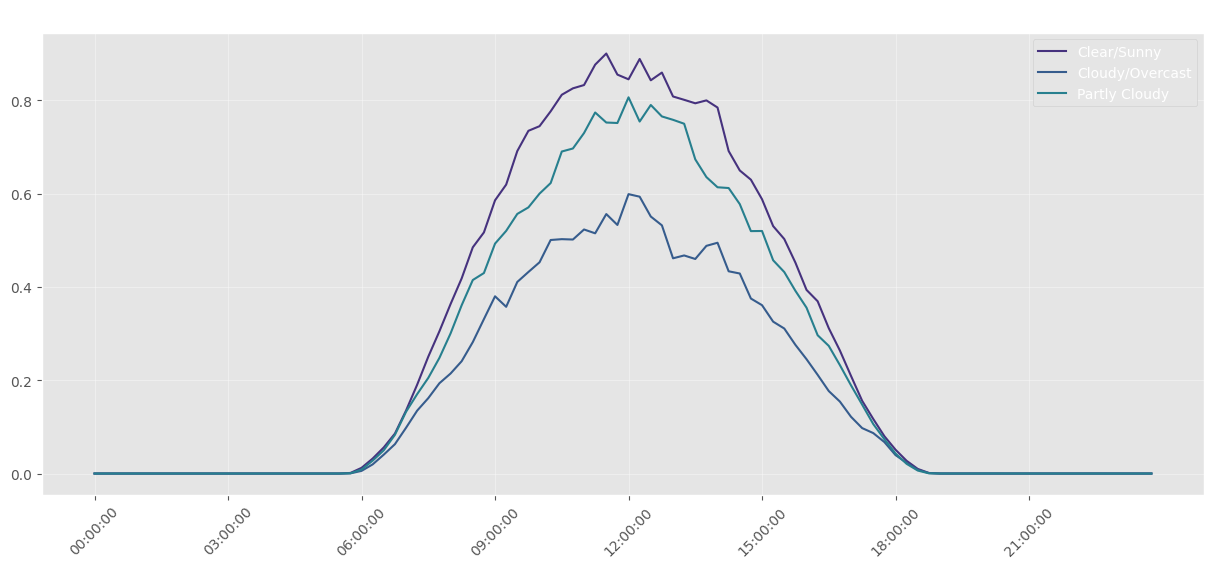

In [4]:
# Merge scenario labels back to the original timeseries
weather_with_scenarios = pd.merge(weather, daily_weather[['DATE', 'PLANT_ID', 'SCENARIO']], on=['DATE', 'PLANT_ID'])

# Normalize time to "minutes from midnight"
weather_with_scenarios['TIME'] = weather_with_scenarios['DATE_TIME'].dt.time

scenario_profiles = weather_with_scenarios.groupby(['SCENARIO', 'TIME'])[['IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE']].mean().reset_index()

plt.figure(figsize=(15, 6))
for scenario in scenario_profiles['SCENARIO'].unique():
    subset = scenario_profiles[scenario_profiles['SCENARIO'] == scenario]
    plt.plot(subset['TIME'].astype(str), subset['IRRADIATION'], label=scenario)

plt.xticks(scenario_profiles['TIME'].astype(str).unique()[::12], rotation=45)
plt.title('Average Irradiation Profiles by Scenario')
plt.legend()
plt.show()

## 4. Exporting Scenarios

These profiles will be used as inputs for our prediction model.

In [5]:
scenario_profiles.to_csv('weather_scenarios.csv', index=False)
print("Scenarios saved to weather_scenarios.csv")

Scenarios saved to weather_scenarios.csv
